## Imports das Bibliotecas

In [46]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
import numpy as np 

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# DESENVOLVER O MODELO SEM VIES 

# Analise dos dados

In [47]:
df1 = pd.read_csv("./datasets/Coleta_Brancas.csv")
df2 = pd.read_csv("./datasets/Coleta_Negras.csv")
df3 = pd.read_csv("./datasets/Coleta_Pardas.csv")

df = pd.concat([df1, df2, df3])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1226 entries, 0 to 370
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           1226 non-null   object
 1   Original_Text  1226 non-null   object
 2   Cor            1226 non-null   object
 3   Conclusao      359 non-null    object
dtypes: object(4)
memory usage: 47.9+ KB


In [48]:
df = df.rename(columns={'Name': 'name', 'Original_Text':'ementa' , 'Cor': 'cor', 'Conclusao': 'conclusao'})
df['conclusao'] = df['conclusao'].fillna('VAZIO')
df

,name,ementa,cor,conclusao
0,Adilson Candido Da Silva,\nExcelentíssimo(a) Senhor(a) Doutor(a) Juiz(a...,Branca,VAZIO
1,Adilson Candido Da Silva,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA ...,Branca,VAZIO
2,Adilson Candido Da Silva,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ DE DIREITO ...,Branca,VAZIO
3,Adilson Candido Da Silva,\nFls.: 2\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ D...,Branca,GANHO
4,Adilson Candido Da Silva,EXMO. SR. DR. JUIZ DE DIREITO DA 7º VARA CÍVE...,Branca,PERDIDO
...,...,...,...,...
366,Weber Lasaro De Oliveira,\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA...,Parda,AMBIGUO
367,Weber Lasaro De Oliveira,\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA...,Parda,AMBIGUO
368,Wilson Jose De Araujo,AO JUÍZO DE DIREITO DA VARA DO JUIZADO ESPECI...,Parda,VAZIO
369,Wilson Jose De Araujo,\nEXCELENTÍSSIMA SENHORA DOUTORA JUÍZA DE DIRE...,Parda,PERDIDO


In [49]:
# Remova duplicatas apenas da coluna A e concatene os valores correspondentes em uma única instância
df = df.groupby('name').agg(lambda x: ', '.join(x.unique())).reset_index()

In [50]:
df['cor'].value_counts()

cor
Branca    86
Parda     56
Negra     23
Name: count, dtype: int64

In [51]:
# # y_pred = model_LR.predict(X)
# # rng = np.random.default_rng(42)
# rng = np.random.default_rng(62)
# numbers = rng.random(len(df))
# balanceamento = [df.loc[df["cor"] == "BRANCA"].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 'OUTROS'].sample(1) for i in numbers]
# df = pd.concat(balanceamento)


In [52]:
# df["nome"].value_counts().unique()
df["ementa"].count()

165

In [53]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,Branca,86
1,Parda,56
2,Negra,23


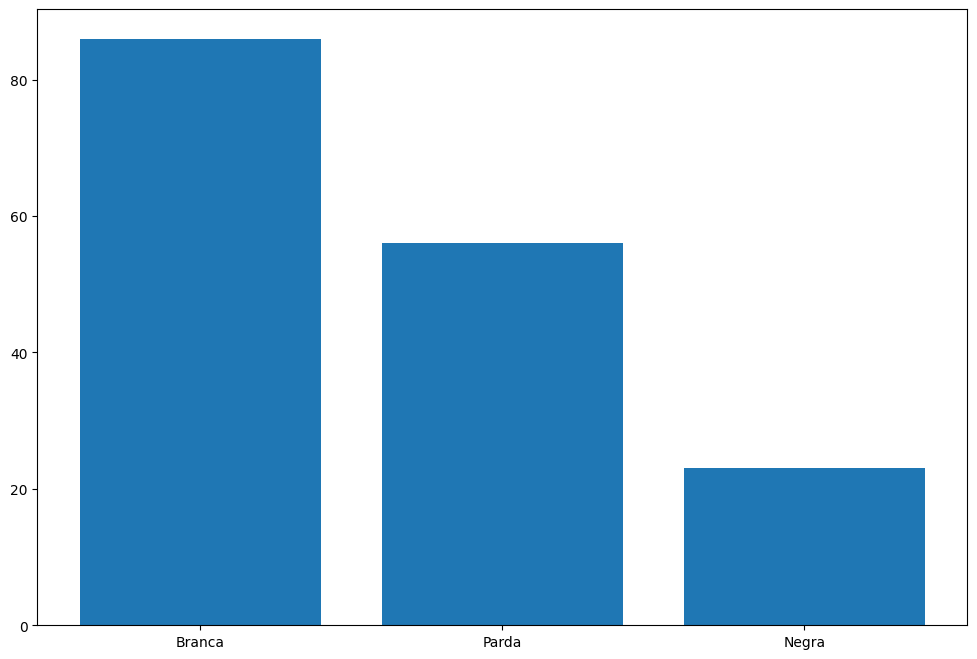

In [54]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [55]:
df["ementa"].dropna().count()

165

## Bag Of Words

In [56]:
# nltk.download('stopwords')

In [57]:
stop_words = list(stopwords.words('portuguese'))

stopword = ['00', '00b', '00da', '0000do', 'ao', '00do', '00no', '00ao', '00mai', '00pelo', '00extra', '00pago', '2oo', '00o']

for i in stopword:
    stop_words.append(i)

In [58]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [59]:
tf_idf = TfidfVectorizer(stop_words=list(stop_words), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


In [60]:
print(list(stop_words))


['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'éramos', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estar', 'estas', 'estava', 'estavam', 'estávamos', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estivéramos', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'fôramos', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'há', 'haja', 'hajam', 'hajamos', 'hão', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houverá', 'houveram', 'houvéramos', 'houverão', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houveríamos', 'houvermos', 'houvesse', 'houvessem', 'houvésse

## WORD CLOUD

In [61]:
le = LabelEncoder()

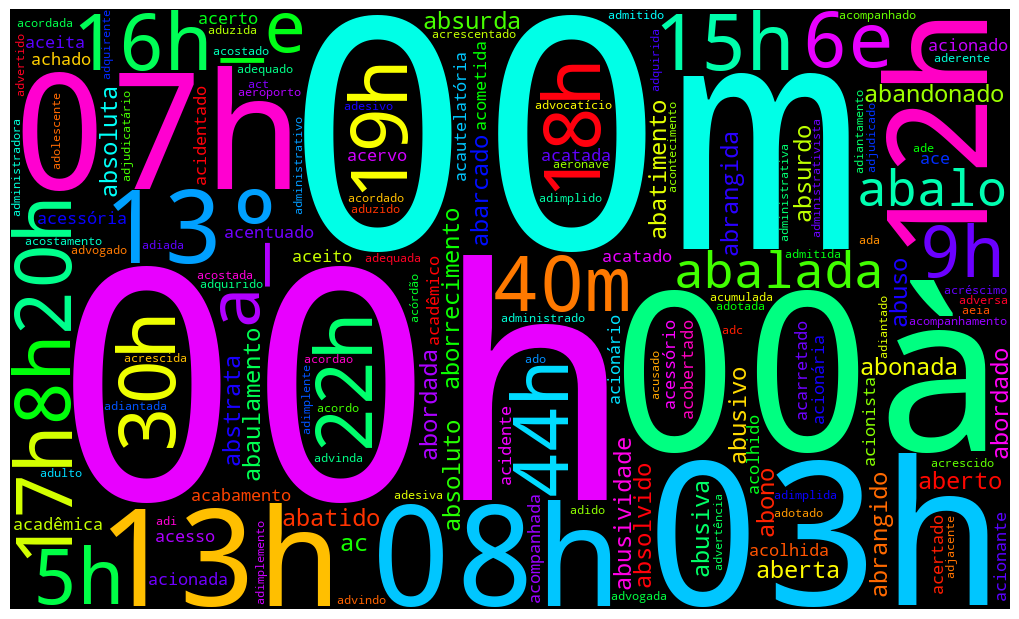

In [62]:
# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='gist_rainbow',
    min_font_size=10).generate(vocab)

plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [63]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

## Treino do Modelo

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [66]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", 'Pardos', 'Negros'])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [67]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=False) 

# Logistic Regression

In [68]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results_f1_scoreLR = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyLR = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreLR)


print("Media da Accuracy: ", cross_val_results_accuracyLR.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracyLR.std())
print('')

print("Media da MACRO F1: ", cross_val_results_f1_scoreLR.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreLR.std())

Resultado da Cross Validation:  [0.29112834 0.26861702 0.4225     0.1969697  0.1300813 ]
Media da Accuracy:  0.4424242424242424
Desvio Padrão da Accuracy:  0.11594622102853935

Media da MACRO F1:  0.26185927133985326
Desvio Padrão da MACRO F1:  0.09826889590187211


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.50      0.75      0.60        16
           1       0.00      0.00      0.00         3
           2       0.33      0.07      0.12        14

    accuracy                           0.39        33
   macro avg       0.28      0.27      0.24        33
weighted avg       0.38      0.39      0.34        33



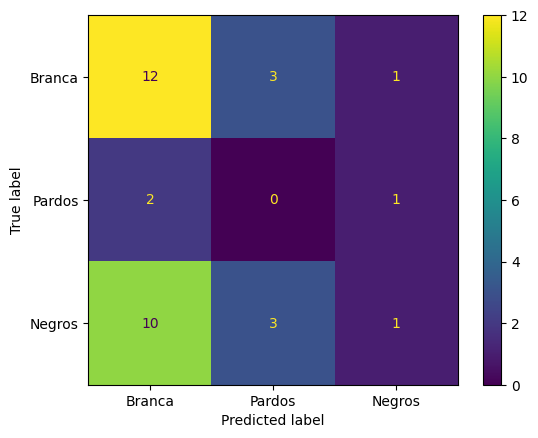

In [69]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [70]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results_f1_scoreSGD = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracySGD = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreSGD)

print("Media da Accuracy: ", cross_val_results_accuracySGD.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracySGD.std())

print("Media da MACRO F1: ", cross_val_results_f1_scoreSGD.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreSGD.std())

Resultado da Cross Validation:  [0.31039136 0.17094017 0.28888889 0.225      0.13675214]
Media da Accuracy:  0.3696969696969697
Desvio Padrão da Accuracy:  0.09070684573997434
Media da MACRO F1:  0.2263945119208277
Desvio Padrão da MACRO F1:  0.0664438141149009


# K Neighbors Classifier

In [71]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results_f1_scoreKN = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracyKN = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreKN)

print("Media da Accuracy: ", cross_val_results_accuracyKN.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracyKN.std())

print("Media da MACRO F1: ", cross_val_results_f1_scoreKN.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreKN.std())

Resultado da Cross Validation:  [0.21114594 0.11658456 0.1087344  0.29429635 0.15925926]
Media da Accuracy:  0.19393939393939394
Desvio Padrão da Accuracy:  0.08040302522073696
Media da MACRO F1:  0.1780041032160174
Desvio Padrão da MACRO F1:  0.06862111583584683


Classification Report for Data Test
              precision    recall  f1-score   support

           0       1.00      0.06      0.12        16
           1       0.04      0.33      0.07         3
           2       0.00      0.00      0.00        14

    accuracy                           0.06        33
   macro avg       0.35      0.13      0.06        33
weighted avg       0.49      0.06      0.06        33



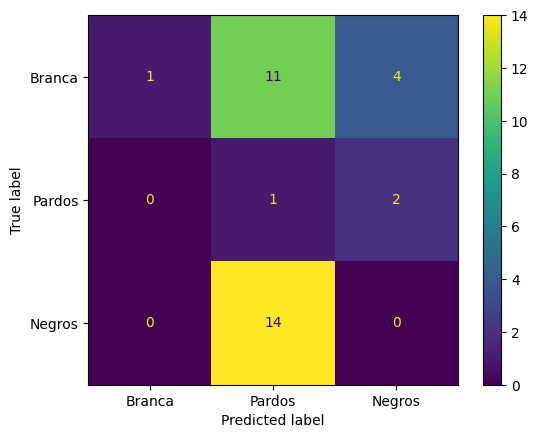

In [72]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [73]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results_f1_scoreSVM = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracySVM = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreSVM)

print("Media da Accuracy: ", cross_val_results_accuracySVM.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracySVM.std())

print("Media da MACRO F1: ", cross_val_results_f1_scoreSVM.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreSVM.std())

Resultado da Cross Validation:  [0.34528934 0.21937984 0.23030303 0.16666667 0.15511163]
Media da Accuracy:  0.37575757575757573
Desvio Padrão da Accuracy:  0.0950568917658068
Media da MACRO F1:  0.22335010210994674
Desvio Padrão da MACRO F1:  0.06753189350143972


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.46      0.69      0.55        16
           1       0.00      0.00      0.00         3
           2       0.40      0.14      0.21        14

    accuracy                           0.39        33
   macro avg       0.29      0.28      0.25        33
weighted avg       0.39      0.39      0.36        33



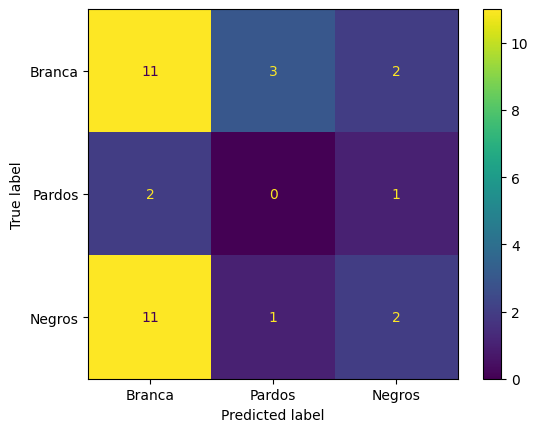

In [74]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [75]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results_f1_scoreRF = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyRF = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results_f1_scoreRF)

print("Media da Accuracy: ", cross_val_results_accuracyRF.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracyRF.std())

print("Media da MACRO F1: ", cross_val_results_f1_scoreRF.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreRF.std())

Resultado da Cross Validation:  [0.24489796 0.29128205 0.37735849 0.28684003 0.1300813 ]
Media da Accuracy:  0.49090909090909085
Desvio Padrão da Accuracy:  0.13054944986992736
Media da MACRO F1:  0.2660919666731306
Desvio Padrão da MACRO F1:  0.0804901845915625


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.48      0.81      0.60        16
           1       0.00      0.00      0.00         3
           2       0.33      0.14      0.20        14

    accuracy                           0.45        33
   macro avg       0.27      0.32      0.27        33
weighted avg       0.37      0.45      0.38        33



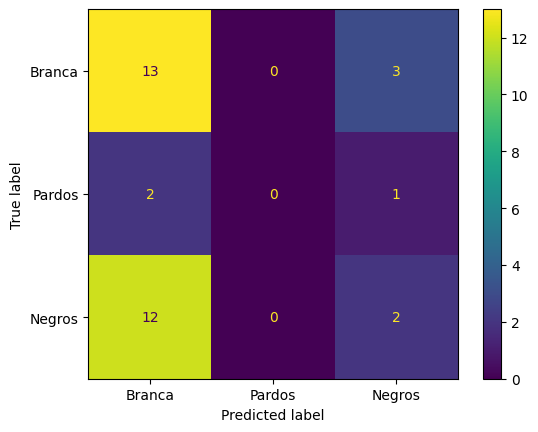

In [76]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [77]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results_f1_scoreDT = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyDT = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreDT)

print("Media da Accuracy: ", cross_val_results_accuracyDT.mean())
print("Desvio Padrão da Accuracy: ", cross_val_results_accuracyDT.std())

print("Media da MACRO F1: ", cross_val_results_f1_scoreDT.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreDT.std())

Resultado da Cross Validation:  [0.29868578 0.2505978  0.22312191 0.33928571 0.41013825]
Media da Accuracy:  0.40606060606060607
Desvio Padrão da Accuracy:  0.030903148567228995
Media da MACRO F1:  0.30436589062369446
Desvio Padrão da MACRO F1:  0.06622845590320944


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.46      0.75      0.57        16
           1       0.00      0.00      0.00         3
           2       0.33      0.14      0.20        14

    accuracy                           0.42        33
   macro avg       0.26      0.30      0.26        33
weighted avg       0.37      0.42      0.36        33



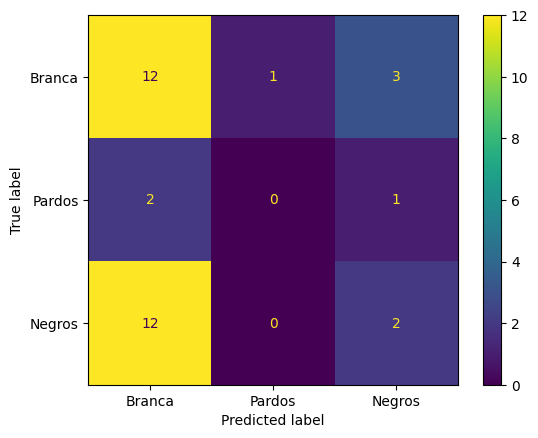

In [78]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [79]:
## Funçao para Avaliação dos Modelos
# Refazer essa parte 
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

branca:int = df["cor"].loc[(df["cor"] == 0)].value_counts()
# print(int(branca))
prob_branca = (int(branca)/len(df["cor"]))

parda:int = df["cor"].loc[(df["cor"] == 1)].value_counts()

prob_parda = (int(parda)/len(df["cor"]))

negra:int = df["cor"].loc[(df["cor"] == 2)].value_counts()

prob_negra = (int(negra)/len(df["cor"]))


resultado_sem_vies_accuracy = []
resultado_sem_vies_f1_score = []
rng_options = [8, 32, 42, 64, 128]
for _ in range(5):
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    sem_vies = []
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    for i in numbers:

        if i < prob_branca:
            aux = df.loc[df["cor"] == 0].sample(1)

        elif i > prob_branca and i < prob_branca + prob_parda:
            aux = df.loc[df["cor"] == 2].sample(1)

        elif i > prob_branca + prob_parda:
            aux = df.loc[df["cor"] == 1].sample(1)

        sem_vies.append(aux)

    new_df = pd.concat(sem_vies)  
        
    resultado_sem_vies_f1_score.append(f1_score(y_test, new_df['cor'], average='macro'))
    resultado_sem_vies_accuracy.append(accuracy_score(y_test, new_df['cor']))

In [92]:
sem_vies_accuracy = pd.DataFrame(resultado_sem_vies_accuracy)
sem_vies_f1_score = pd.DataFrame(resultado_sem_vies_f1_score)

print(f' Média da Accuracy: {sem_vies_accuracy.mean()[0]}')
print(f' Desvio Padrão Accuracy: {sem_vies_accuracy.std()[0]}')

print('\n')

print(f' Média da Macro F1: {sem_vies_f1_score.mean()[0]}')
print(f' Desvio Padrão da Macro F1: {sem_vies_f1_score.std()[0]}')


 Média da Accuracy: 0.3878787878787878
 Desvio Padrão Accuracy: 0.08677467311076578


 Média da Macro F1: 0.3240156323438057
 Desvio Padrão da Macro F1: 0.08400611428883059


# Aleatório

In [80]:
resultado_aleatorio_f1_score = []
resultado_aleatorio_accuracy = []
rng_options = [8, 32, 42, 64, 1]

for _ in range(5):
    aleatorio = []
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    for i in range(int(len(numbers))):

        if numbers[i] < 0.333:  
            aleatorio.append(y_test.loc[y_test == 0].sample(1))
        elif numbers[i] > 0.333 and numbers[i] < 0.666:
            aleatorio.append(y_test.loc[y_test == 1].sample(1))

        elif numbers[i] > 0.666:
            aleatorio.append(y_test.loc[y_test == 2].sample(1))

    new_df = pd.concat(aleatorio)
    
    resultado_aleatorio_accuracy.append(accuracy_score(y_test, new_df))
    resultado_aleatorio_f1_score.append(f1_score(y_test, new_df, average='macro'))


In [81]:
aleatorio_accuracy = pd.DataFrame(resultado_sem_vies_accuracy)
aleatorio_f1_score = pd.DataFrame(resultado_aleatorio_f1_score)

print(f' Média da Accuracy: {aleatorio_accuracy.mean()[0]}')
print(f' Desvio Padrão Accuracy: {aleatorio_accuracy.std()[0]}')

print('\n')

print(f' Média da Macro F1: {aleatorio_f1_score.mean()[0]}')
print(f' Desvio Padrão da Macro F1: {aleatorio_f1_score.std()[0]}')

 Média da Accuracy: 0.3878787878787878
 Desvio Padrão Accuracy: 0.08677467311076578


 Média da Macro F1: 0.32146547502674394
 Desvio Padrão da Macro F1: 0.10120232596195383


# P_VALUE

In [82]:
resultado_melhor_resultado_accuracy = cross_val_results_accuracyRF
resultado_melhor_resultado_f1_score = cross_val_results_f1_scoreRF

# LOGISTIC REGRESSION

In [83]:
from scipy.stats import ttest_rel

p_value_accuracy_aleatorioLR = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyLR)
p_value_f1_score_aleatorioLR = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreLR)

p_value_accuracy_sem_viesLR = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracyLR)
p_value_f1_score_sem_viesLR = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreLR)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracyLR)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreLR)

print('\nALEATÓRIO')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioLR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioLR.pvalue} \n')

print('\nSEM VIÉS')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesLR.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesLR.pvalue} \n')

print('\nMelhor Modelo')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')



ALEATÓRIO
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.5030638652135099 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.527928778747769 


SEM VIÉS
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.3218632595652238 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.28126400984498917 


Melhor Modelo
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.03491970667453909 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.8746399161540885 



# SGD

In [84]:
p_value_accuracy_aleatorioSGD = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracySGD)
p_value_f1_score_aleatorioSGD = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreSGD)

p_value_accuracy_sem_viesSGD = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracySGD)
p_value_f1_score_sem_viesSGD = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreSGD)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracySGD)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreSGD)

print('ALEATÓRIO\n')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioSGD.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioSGD.pvalue} \n')

print('SEM VIÉS\n')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesSGD.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesSGD.pvalue} \n')

print('\nMelhor Modelo')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')


ALEATÓRIO

 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.9999999999999999 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.21788958226276395 

SEM VIÉS

 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.7488684500235268 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.07901108888570522 


Melhor Modelo
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.05083594085586075 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.3029385425741347 



# KNN

In [85]:
p_value_accuracy_aleatorioKN = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyKN)
p_value_f1_score_aleatorioKN = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreKN)

p_value_accuracy_sem_viesKN = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracyKN)
p_value_f1_score_sem_viesKN = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreKN)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracyKN)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreKN)

print('\nALEATÓRIO')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioKN.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioKN.pvalue} \n')

print('\nSEM VIÉS')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesKN.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesKN.pvalue} \n')

print('\nMelhor Modelo')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')



ALEATÓRIO
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.024808233949156884 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.04312990185278764 


SEM VIÉS
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.019362156109293212 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.039473216877255766 


Melhor Modelo
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.0243941389576714 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.1997506936597465 



# SVM

In [86]:
p_value_accuracy_aleatorioSVM = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracySVM)
p_value_f1_score_aleatorioSVM = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreSVM)

p_value_accuracy_sem_viesSVM = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracySVM)
p_value_f1_score_sem_viesSVM = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreSVM)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracySVM)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreSVM)


print('\nALEATÓRIO')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioSVM.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioSVM.pvalue} \n')

print('\nSEM VIÉS')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesSVM.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesSVM.pvalue} \n')

print('\nMelhor Modelo')
print(f' Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')



ALEATÓRIO
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.9450688407929766 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.2080542397742764 


SEM VIÉS
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.764805599024977 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.05672885168589512 


Melhor Modelo
 Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.048742092653967284 

 Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.40784340798527496 



# Random Forest

In [87]:
p_value_accuracy_aleatorioRF = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyRF)
p_value_f1_score_aleatorioRF = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreRF)

p_value_accuracy_sem_viesRF = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracyRF)
p_value_f1_score_sem_viesRF = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreRF)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracyRF)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreRF)

print('\nALEATÓRIO')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioRF.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioRF.pvalue} \n')

print('\nSEM VIÉS')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesRF.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesRF.pvalue} \n')

print('\nMelhor Modelo')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')



ALEATÓRIO
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.319430216942661 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.5345518895897275 


SEM VIÉS
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.1007732200325571 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.1850071946206688 


Melhor Modelo
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  nan 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  nan 



# Decision Tree

In [88]:
p_value_accuracy_aleatorioDT = ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyDT)
p_value_f1_score_aleatorioDT = ttest_rel(resultado_aleatorio_f1_score, cross_val_results_f1_scoreDT)

p_value_accuracy_sem_viesDT = ttest_rel(resultado_sem_vies_accuracy, cross_val_results_accuracyDT)
p_value_f1_score_sem_viesDT = ttest_rel(resultado_sem_vies_f1_score, cross_val_results_f1_scoreDT)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, cross_val_results_accuracyDT)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, cross_val_results_f1_scoreDT)


print('\nALEATÓRIO')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_aleatorioDT.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_aleatorioDT.pvalue} \n')

print('\nSEM VIÉS')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_sem_viesDT.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_sem_viesDT.pvalue} \n')

print('\nMelhor Modelo')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')


ALEATÓRIO
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.4144300825009167 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.4548196849134151 


SEM VIÉS
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.704 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.7749876338803579 


Melhor Modelo
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.3383068873788801 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.6207356869905649 



# Sem Vies

In [89]:

p_value_accuracy_sem_vies = ttest_rel(resultado_sem_vies_accuracy, resultado_sem_vies_accuracy)
p_value_f1_score_sem_vies = ttest_rel(resultado_sem_vies_f1_score, resultado_sem_vies_f1_score)

p_value_accuracy_aleatorio = ttest_rel(resultado_sem_vies_accuracy, resultado_aleatorio_accuracy)
p_value_f1_score_aleatorio = ttest_rel(resultado_sem_vies_f1_score, resultado_aleatorio_f1_score)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, resultado_sem_vies_accuracy)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, resultado_sem_vies_f1_score)




print('\nALEATÓRIO')
print(f' Valor do P_VALUE para ACURÁCIA DE SEM VIES:  {p_value_accuracy_aleatorio.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE SEM VIES:  {p_value_f1_score_aleatorio.pvalue} \n')

print('\nSEM VIES')
print(f'Valor do P_VALUE para ACURÁCIA DE SEM VIES:  {p_value_accuracy_sem_vies.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE SEM VIES:  {p_value_f1_score_sem_vies.pvalue} \n')

print('\nMelhor Modelo')
print(f'Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f'Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  {p_value_f1_score_melhor_resultado.pvalue} \n')


ALEATÓRIO
 Valor do P_VALUE para ACURÁCIA DE SEM VIES:  0.8288168431112577 

 Valor do P_VALUE para MACRO F1 DE SEM VIES:  0.9762439689948186 


SEM VIES
Valor do P_VALUE para ACURÁCIA DE SEM VIES:  nan 

Valor do P_VALUE para MACRO F1 DE SEM VIES:  nan 


Melhor Modelo
Valor do P_VALUE para ACURÁCIA DE LOGISTIC REGRESSION:  0.1007732200325571 

Valor do P_VALUE para MACRO F1 DE LOGISTIC REGRESSION:  0.1850071946206688 



# Aleatório

In [90]:

p_value_accuracy_aleatorio = ttest_rel(resultado_aleatorio_accuracy, resultado_aleatorio_accuracy)
p_value_f1_score_aleatorio = ttest_rel(resultado_aleatorio_f1_score, resultado_aleatorio_f1_score)

p_value_accuracy_sem_vies = ttest_rel(resultado_sem_vies_accuracy, resultado_aleatorio_accuracy)
p_value_f1_score_sem_vies = ttest_rel(resultado_sem_vies_f1_score, resultado_aleatorio_f1_score)

p_value_accuracy_melhor_resultado = ttest_rel(resultado_melhor_resultado_accuracy, resultado_aleatorio_accuracy)
p_value_f1_score_melhor_resultado = ttest_rel(resultado_melhor_resultado_f1_score, resultado_aleatorio_f1_score)

print('Aleatório')
print(f' Valor do P_VALUE para ACURÁCIA DE ALEATÓRIO:  {p_value_accuracy_aleatorio.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE ALEATÓRIO:  {p_value_f1_score_aleatorio.pvalue} \n')

print('SEM VIES')
print(f' Valor do P_VALUE para ACURÁCIA DE SEM VIES:  {p_value_accuracy_sem_vies.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE SEM VIES:  {p_value_f1_score_sem_vies.pvalue} \n')

print('MELHOR RESULTADO')
print(f' Valor do P_VALUE para ACURÁCIA DE MELHOR RESULTADO:  {p_value_accuracy_melhor_resultado.pvalue} \n')
print(f' Valor do P_VALUE para MACRO F1 DE MELHOR RESULTADO:  {p_value_f1_score_melhor_resultado.pvalue} \n')


Aleatório
 Valor do P_VALUE para ACURÁCIA DE ALEATÓRIO:  nan 

 Valor do P_VALUE para MACRO F1 DE ALEATÓRIO:  nan 

SEM VIES
 Valor do P_VALUE para ACURÁCIA DE SEM VIES:  0.8288168431112577 

 Valor do P_VALUE para MACRO F1 DE SEM VIES:  0.9762439689948186 

MELHOR RESULTADO
 Valor do P_VALUE para ACURÁCIA DE MELHOR RESULTADO:  0.319430216942661 

 Valor do P_VALUE para MACRO F1 DE MELHOR RESULTADO:  0.5345518895897275 

